# UK Crime Analysis - Exploratory Data Analysis (EDA)

This notebook performs exploratory data analysis on UK street-level crime data obtained from the UK Police open data platform.

The dataset contains crime records from four police forces between **January 2024 and December 2025**:

- Metropolitan Police Service
- West Midlands Police
- Dyfed-Powys Police
- North Yorkshire Police

These police forces were selected to represent a mix of **urban and rural regions**, enabling comparisons between different types of areas.

The objective of this analysis is to explore crime patterns across these regions in order to provide insights that may help identify which locations are more or less desirable for real estate activity. The analysis focuses on crime distribution, crime types, geographic patterns, and trends over time.

The findings from this exploratory analysis will support the selection of **two police forces for further investigation in the next stage of the project.**

### Import Required Libraries

The pandas library is used for data manipulation and analysis.

The numpy library is used for numerical operations.

The matplotlib library is used for plotting charts.

The seaborn library is used to create cleaner and nicer looking visualisatiions.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

### Define File Paths

Relative file paths are used to ensure that the notebook can be run on other machines without modification.

In [ ]:
DATA_SAMPLE = "../data_sample/"
DATA_RAW = "../data_raw/"
DATA_CLEAN = "../data_clean/"

## Load and Inspect cleaned data



In [ ]:
df = pd.read_csv(DATA_CLEAN + "crime_cleaned.csv")

In [ ]:
df.head()

,Crime ID,Month,Reported by,Falls within,Longitude,Latitude,Location,LSOA code,LSOA name,Crime type,Last outcome category,Date,Year_Clean,Month_Clean
0,NaN,2024-01,Dyfed-Powys Police,Dyfed-Powys Police,-4.263992,51.997480,On or near Maes Cader,W01000685,Carmarthenshire 001A,Anti-social behaviour,NaN,2024-01-01,2024,1
1,da71940f89a390386d10cbf21e8ebe80d78636f6938c18...,2024-01,Dyfed-Powys Police,Dyfed-Powys Police,-4.263992,51.997480,On or near Maes Cader,W01000685,Carmarthenshire 001A,Violence and sexual offences,Unable to prosecute suspect,2024-01-01,2024,1
2,c68de8d546cb8c4ed65025c91bc3a830eadf86f967aa75...,2024-01,Dyfed-Powys Police,Dyfed-Powys Police,-4.266129,51.998257,On or near Davies Street,W01000685,Carmarthenshire 001A,Violence and sexual offences,Court result unavailable,2024-01-01,2024,1
3,a3d4f930ef0f8583de6c8470f3d46e6e910c41efc90986...,2024-01,Dyfed-Powys Police,Dyfed-Powys Police,-4.156998,52.071607,On or near Sports/Recreation Area,W01000702,Carmarthenshire 001D,Violence and sexual offences,Court result unavailable,2024-01-01,2024,1
4,01b8122fee9fbd78c212e66e3a80fd9835c35dc731e601...,2024-01,Dyfed-Powys Police,Dyfed-Powys Police,-3.991972,51.992955,On or near Parking Area,W01000650,Carmarthenshire 002B,Violence and sexual offences,Court result unavailable,2024-01-01,2024,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3143284 entries, 0 to 3143283
Data columns (total 14 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Crime ID               object 
 1   Month                  object 
 2   Reported by            object 
 3   Falls within           object 
 4   Longitude              float64
 5   Latitude               float64
 6   Location               object 
 7   LSOA code              object 
 8   LSOA name              object 
 9   Crime type             object 
 10  Last outcome category  object 
 11  Date                   object 
 12  Year_Clean             int64  
 13  Month_Clean            int64  
dtypes: float64(2), int64(2), object(10)
memory usage: 335.7+ MB


In [ ]:
df.shape

(3143284, 14)

### Check date range

In [ ]:
df["Month"].min(), df["Month"].max()

('2024-01', '2025-12')

### Check Police Forces

In [ ]:
df["Falls within"].value_counts()

Falls within
Metropolitan Police Service    2279745
West Midlands Police            664403
North Yorkshire Police          123397
Dyfed-Powys Police               75739
Name: count, dtype: int64

### Creating Urban/Rural column for region type analysis

In [ ]:
area_map = {
    "Metropolitan Police Service": "Urban",
    "West Midlands Police": "Urban",
    "Dyfed-Powys Police": "Rural",
    "North Yorkshire Police": "Rural"
}

df["Area_Type"] = df["Falls within"].map(area_map)

In [ ]:
df.head()

,Crime ID,Month,Reported by,Falls within,Longitude,Latitude,Location,LSOA code,LSOA name,Crime type,Last outcome category,Date,Year_Clean,Month_Clean,Area_Type
0,NaN,2024-01,Dyfed-Powys Police,Dyfed-Powys Police,-4.263992,51.997480,On or near Maes Cader,W01000685,Carmarthenshire 001A,Anti-social behaviour,NaN,2024-01-01,2024,1,Rural
1,da71940f89a390386d10cbf21e8ebe80d78636f6938c18...,2024-01,Dyfed-Powys Police,Dyfed-Powys Police,-4.263992,51.997480,On or near Maes Cader,W01000685,Carmarthenshire 001A,Violence and sexual offences,Unable to prosecute suspect,2024-01-01,2024,1,Rural
2,c68de8d546cb8c4ed65025c91bc3a830eadf86f967aa75...,2024-01,Dyfed-Powys Police,Dyfed-Powys Police,-4.266129,51.998257,On or near Davies Street,W01000685,Carmarthenshire 001A,Violence and sexual offences,Court result unavailable,2024-01-01,2024,1,Rural
3,a3d4f930ef0f8583de6c8470f3d46e6e910c41efc90986...,2024-01,Dyfed-Powys Police,Dyfed-Powys Police,-4.156998,52.071607,On or near Sports/Recreation Area,W01000702,Carmarthenshire 001D,Violence and sexual offences,Court result unavailable,2024-01-01,2024,1,Rural
4,01b8122fee9fbd78c212e66e3a80fd9835c35dc731e601...,2024-01,Dyfed-Powys Police,Dyfed-Powys Police,-3.991972,51.992955,On or near Parking Area,W01000650,Carmarthenshire 002B,Violence and sexual offences,Court result unavailable,2024-01-01,2024,1,Rural


## Chart and Visualisation Building

### Order for bar chart visualtions

In [ ]:
force_order = [
    "Metropolitan Police Service",
    "West Midlands Police",
    "North Yorkshire Police",
    "Dyfed-Powys Police"
]

### Total Crime by Police Force

A bar chart showing total crimes per police force across the full 24 month period.

Text(0.5, 0, '')

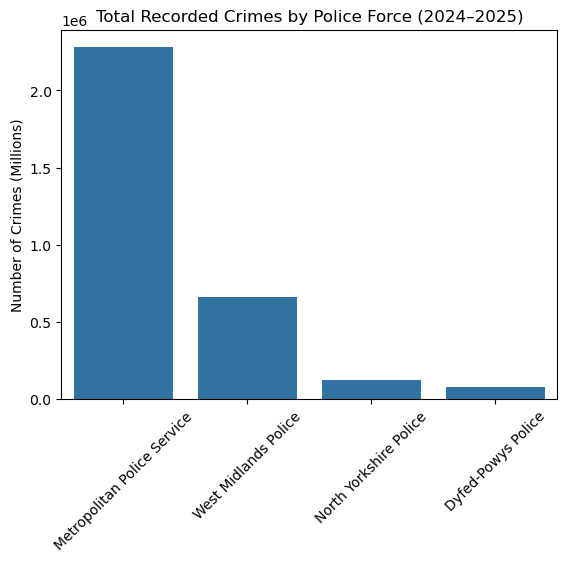

In [ ]:
crime_counts = df["Falls within"].value_counts()

sns.barplot(x=crime_counts.index, y=crime_counts.values, order = force_order)
plt.xticks(rotation=45)
plt.title("Total Recorded Crimes by Police Force (2024–2025)")
plt.ylabel("Number of Crimes (Millions)")
plt.xlabel("")

### Creating approximate population library

Crime volume can be misleading, so a dictionary `population` containing the approximate populations of the regions is created. This allows for adjusted crime rate calculations. Such as, crimes per 10,000 people.

In [ ]:
population = {
    "Metropolitan Police Service": 9000000,
    "West Midlands Police": 2930000,
    "Dyfed-Powys Police": 520000,
    "North Yorkshire Police": 830000
}

### Crimes per 10,000 people

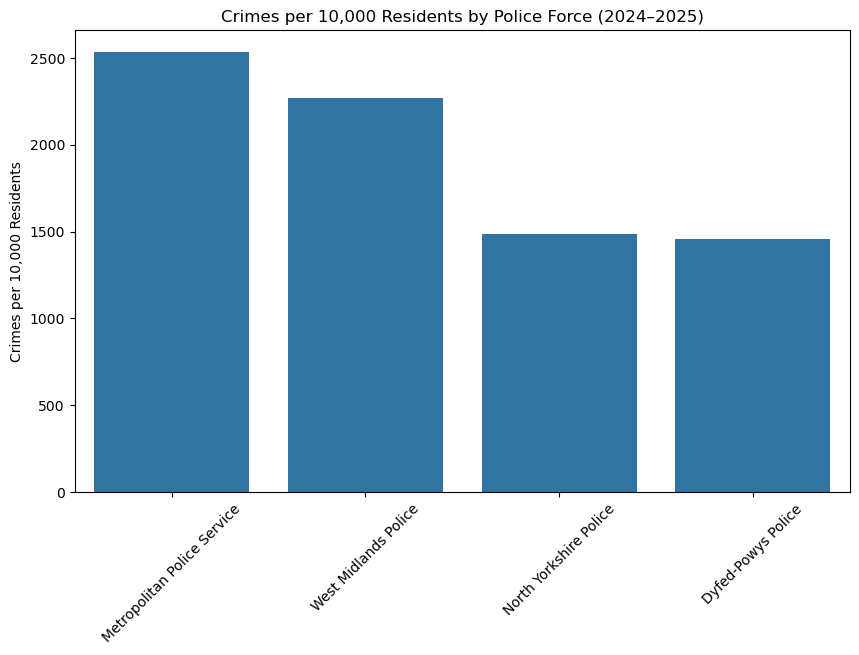

In [ ]:
crime_counts = df.groupby("Falls within").size().reset_index(name="crime_count")
crime_counts["population"] = crime_counts["Falls within"].map(population)
crime_counts["crime_rate_per_10000"] = (crime_counts["crime_count"] / crime_counts["population"]) * 10000

plt.figure(figsize=(10,6))

sns.barplot(data=crime_counts,
            x="Falls within",
            y="crime_rate_per_10000",
            order = force_order)

plt.xticks(rotation=45)
plt.title("Crimes per 10,000 Residents by Police Force (2024–2025)")
plt.ylabel("Crimes per 10,000 Residents")
plt.xlabel("")

plt.show()

### Crime type distribution

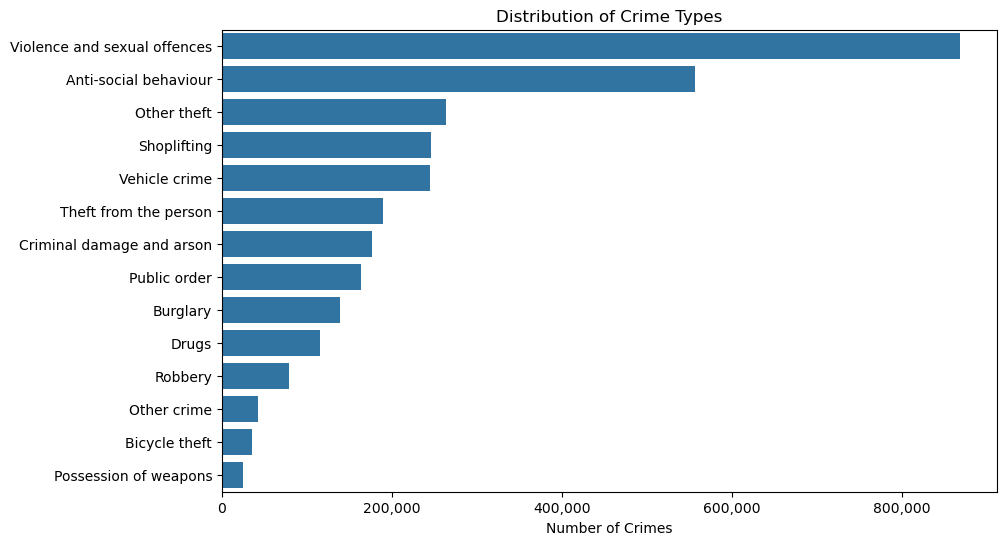

In [ ]:
crime_types = df["Crime type"].value_counts()

plt.figure(figsize=(10,6))

sns.barplot(
    x=crime_types.values,
    y=crime_types.index
)

plt.title("Distribution of Crime Types")
plt.xlabel("Number of Crimes")
plt.ylabel("")

plt.gca().xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.show()

### Crime type by police force

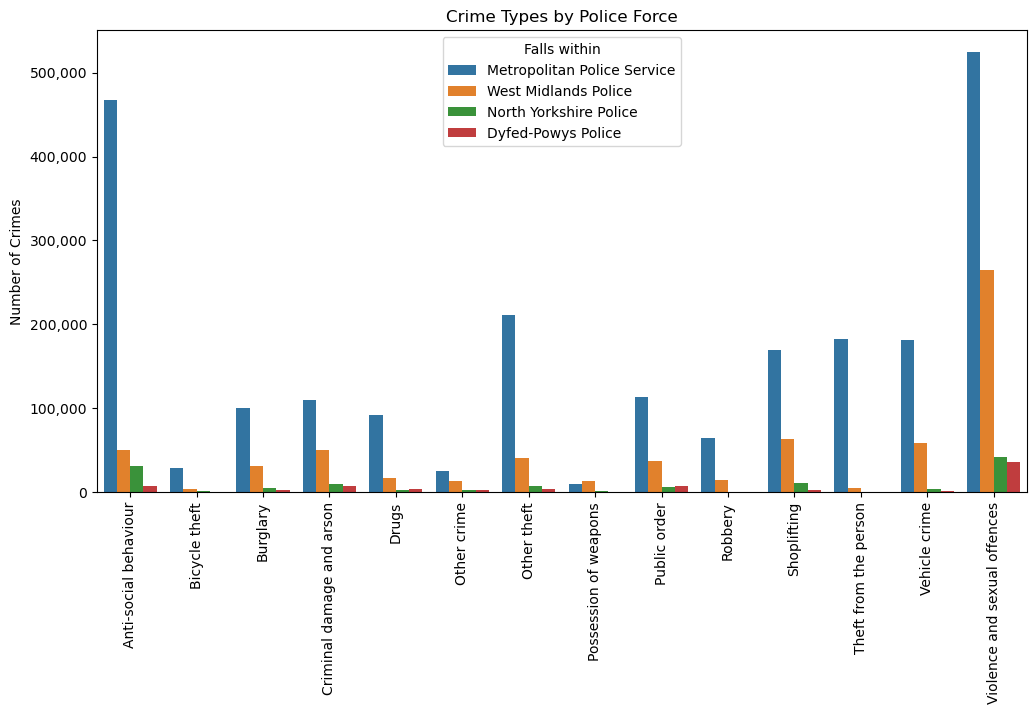

In [ ]:
crime_by_force_type = (
    df.groupby(["Falls within","Crime type"])
    .size()
    .reset_index(name="crime_count")
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=crime_by_force_type,
    x="Crime type",
    y="crime_count",
    hue="Falls within",
    hue_order=force_order
)

plt.xticks(rotation=90)
plt.title("Crime Types by Police Force")
plt.ylabel("Number of Crimes")
plt.xlabel("")


plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.show()

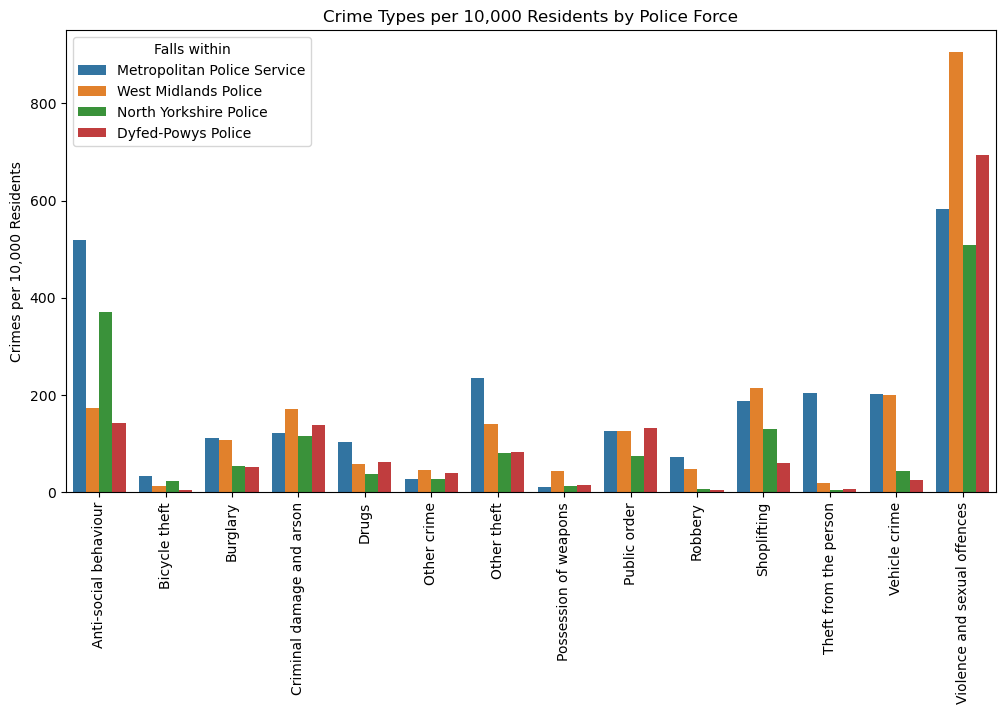

In [ ]:
crime_by_force_type = (
    df.groupby(["Falls within", "Crime type"])
    .size()
    .reset_index(name="crime_count")
)

crime_by_force_type["population"] = crime_by_force_type["Falls within"].map(population)

crime_by_force_type["crime_rate_per_10000"] = (
    crime_by_force_type["crime_count"] / crime_by_force_type["population"]
) * 10000

plt.figure(figsize=(12,6))

sns.barplot(
    data=crime_by_force_type,
    x="Crime type",
    y="crime_rate_per_10000",
    hue="Falls within",
    hue_order=force_order
)

plt.xticks(rotation=90)
plt.title("Crime Types per 10,000 Residents by Police Force")
plt.ylabel("Crimes per 10,000 Residents")
plt.xlabel("")

plt.show()

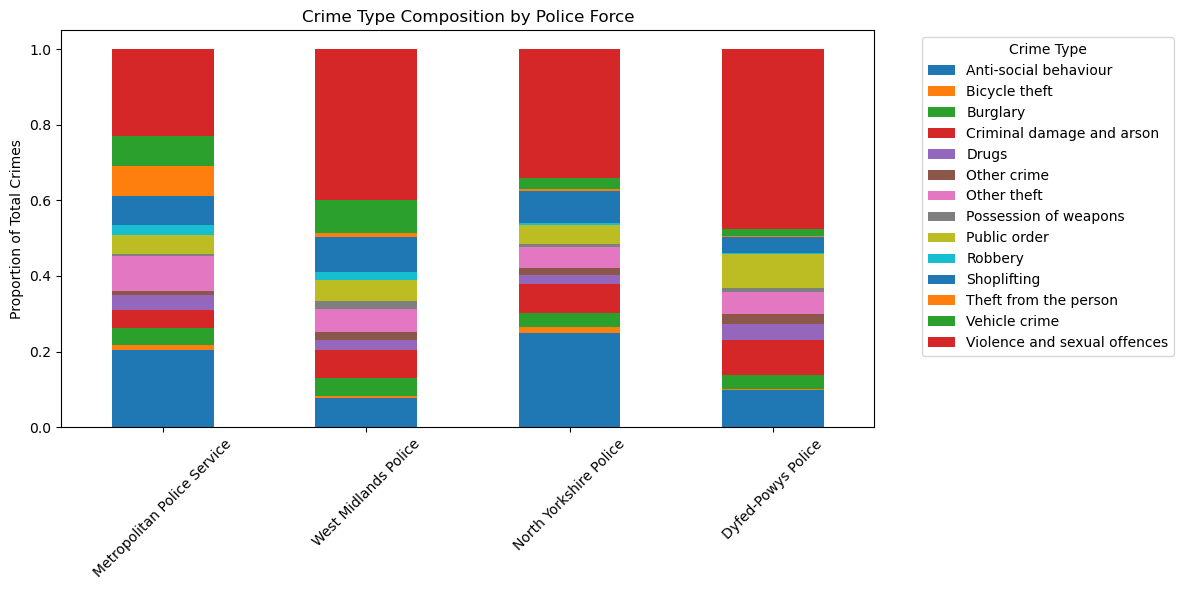

In [ ]:
crime_mix = (
    df.groupby(["Falls within", "Crime type"])
    .size()
    .reset_index(name="crime_count")
)

crime_mix["total_force_crime"] = crime_mix.groupby("Falls within")["crime_count"].transform("sum")
crime_mix["proportion"] = crime_mix["crime_count"] / crime_mix["total_force_crime"]

crime_mix_pivot = crime_mix.pivot(
    index="Falls within",
    columns="Crime type",
    values="proportion"
).fillna(0)

crime_mix_pivot = crime_mix_pivot.reindex(force_order)

crime_mix_pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("Crime Type Composition by Police Force")
plt.ylabel("Proportion of Total Crimes")
plt.xlabel("")
plt.xticks(rotation=45)
plt.legend(title="Crime Type", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Reverse legend for clarity

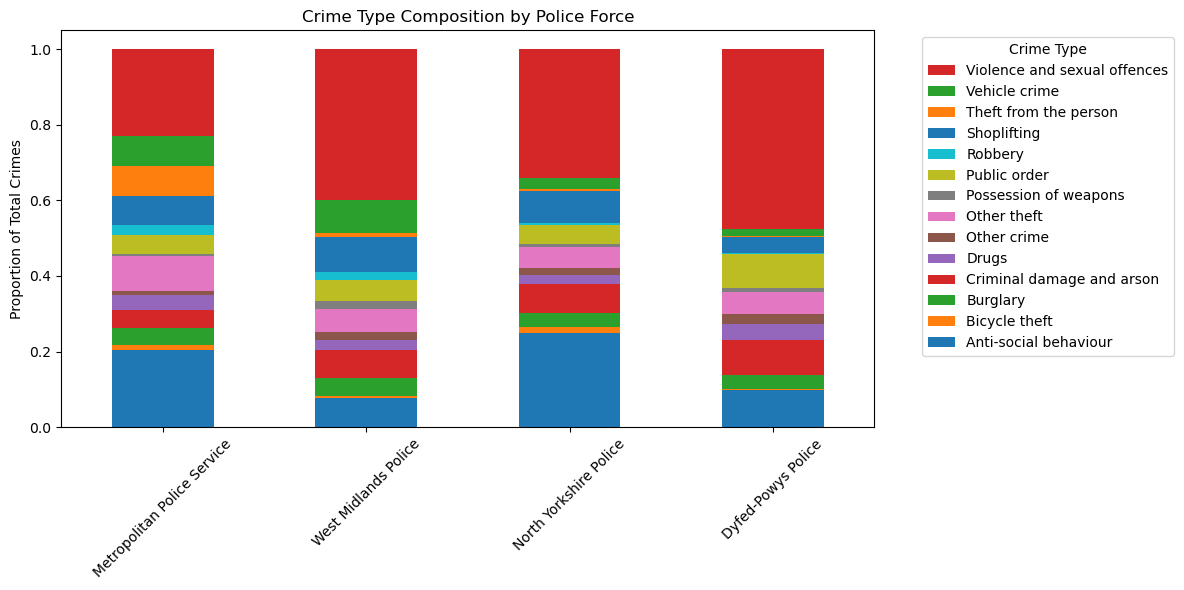

In [ ]:
crime_mix = (
    df.groupby(["Falls within", "Crime type"])
    .size()
    .reset_index(name="crime_count")
)

crime_mix["total_force_crime"] = crime_mix.groupby("Falls within")["crime_count"].transform("sum")
crime_mix["proportion"] = crime_mix["crime_count"] / crime_mix["total_force_crime"]

crime_mix_pivot = crime_mix.pivot(
    index="Falls within",
    columns="Crime type",
    values="proportion"
).fillna(0)

crime_mix_pivot = crime_mix_pivot.reindex(force_order)

ax = crime_mix_pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("Crime Type Composition by Police Force")
plt.ylabel("Proportion of Total Crimes")
plt.xlabel("")
plt.xticks(rotation=45)

# Reverse legend order only
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1],
          title="Crime Type",
          bbox_to_anchor=(1.05, 1),
          loc="upper left")

plt.tight_layout()
plt.show()

### Monthly Crime Trend

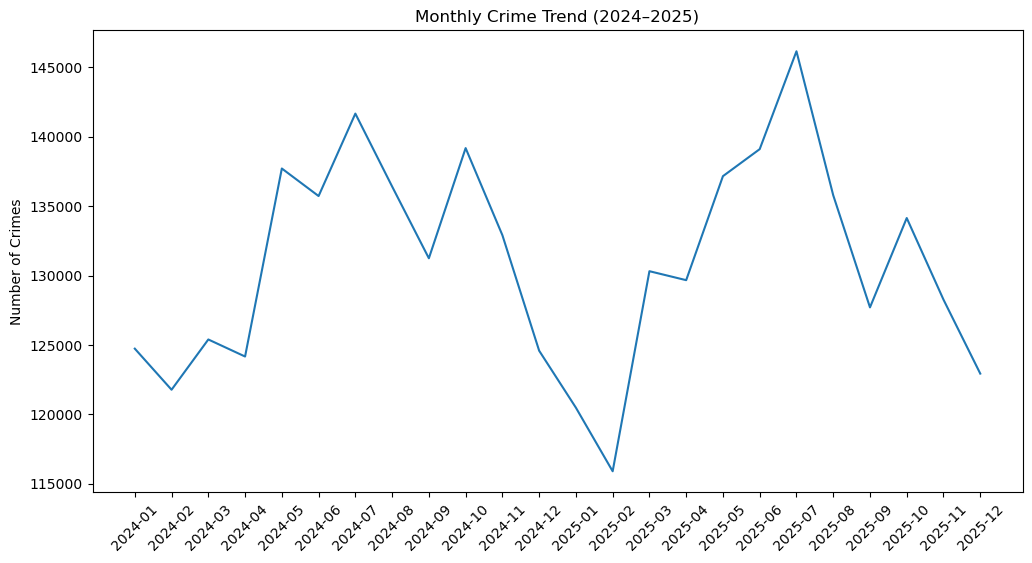

In [ ]:
monthly_crime = df.groupby("Month").size().reset_index(name="crime_count")

plt.figure(figsize=(12,6))

sns.lineplot(
    data=monthly_crime,
    x="Month",
    y="crime_count"
)

plt.xticks(rotation=45)
plt.title("Monthly Crime Trend (2024–2025)")
plt.ylabel("Number of Crimes")
plt.xlabel("")

plt.show()

### Monthly Crime Trend by Police Force

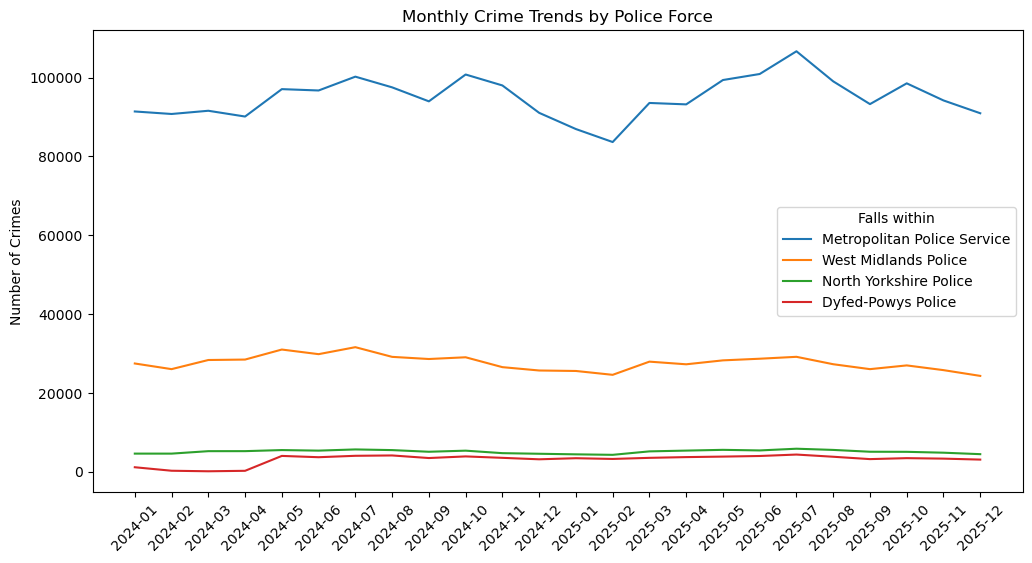

In [ ]:
monthly_force = (
    df.groupby(["Month","Falls within"])
    .size()
    .reset_index(name="crime_count")
)

plt.figure(figsize=(12,6))

sns.lineplot(
    data=monthly_force,
    x="Month",
    y="crime_count",
    hue="Falls within",
    hue_order=force_order
)

plt.xticks(rotation=45)
plt.title("Monthly Crime Trends by Police Force")
plt.ylabel("Number of Crimes")
plt.xlabel("")

plt.show()

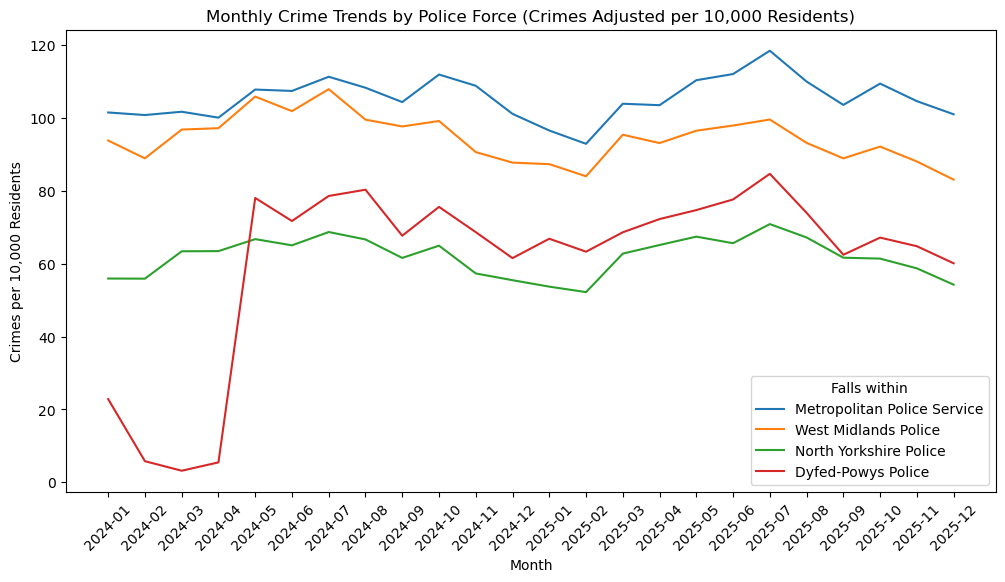

In [ ]:
monthly_force = (
    df.groupby(["Month","Falls within"])
    .size()
    .reset_index(name="crime_count")
)

# Add population
monthly_force["population"] = monthly_force["Falls within"].map(population)

# Calculate crimes per 10k residents
monthly_force["crime_rate_per_10000"] = (
    monthly_force["crime_count"] / monthly_force["population"]
) * 10000


plt.figure(figsize=(12,6))

sns.lineplot(
    data=monthly_force,
    x="Month",
    y="crime_rate_per_10000",
    hue="Falls within",
    hue_order=force_order
)

plt.xticks(rotation=45)
plt.title("Monthly Crime Trends by Police Force (Crimes Adjusted per 10,000 Residents)")
plt.ylabel("Crimes per 10,000 Residents")
plt.xlabel("Month")

plt.show()

### Urban vs Rural

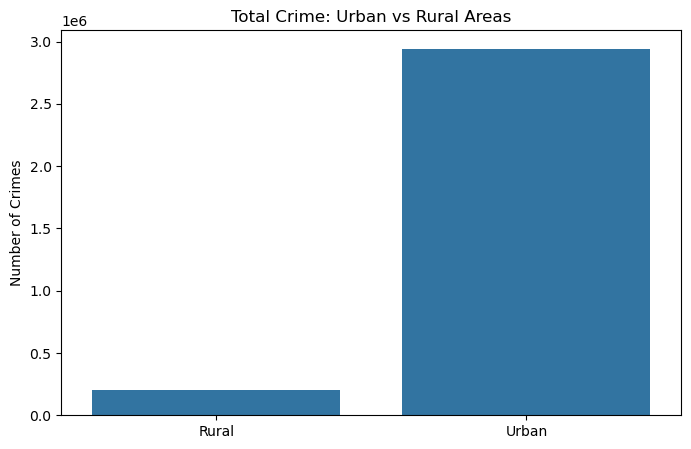

In [ ]:
urban_rural_counts = df.groupby("Area_Type").size().reset_index(name="crime_count")

plt.figure(figsize=(8,5))

sns.barplot(
    data=urban_rural_counts,
    x="Area_Type",
    y="crime_count"
)

plt.title("Total Crime: Urban vs Rural Areas")
plt.ylabel("Number of Crimes")
plt.xlabel("")

plt.show()

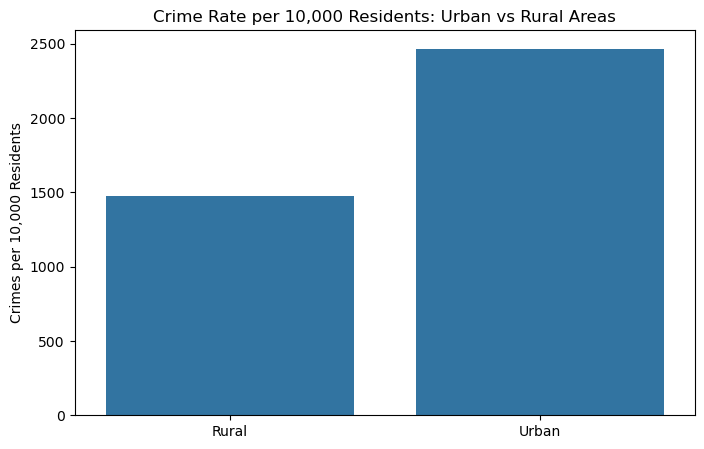

In [ ]:
# Total crimes by area type
urban_rural_counts = (
    df.groupby("Area_Type")
    .size()
    .reset_index(name="crime_count")
)

# Population by area type
population_area = {
    "Urban": population["Metropolitan Police Service"] + population["West Midlands Police"],
    "Rural": population["North Yorkshire Police"] + population["Dyfed-Powys Police"]
}

urban_rural_counts["population"] = urban_rural_counts["Area_Type"].map(population_area)

# Crimes per 10k residents
urban_rural_counts["crime_rate_per_10000"] = (
    urban_rural_counts["crime_count"] / urban_rural_counts["population"]
) * 10000


plt.figure(figsize=(8,5))

sns.barplot(
    data=urban_rural_counts,
    x="Area_Type",
    y="crime_rate_per_10000"
)

plt.title("Crime Rate per 10,000 Residents: Urban vs Rural Areas")
plt.ylabel("Crimes per 10,000 Residents")
plt.xlabel("")

plt.show()

### Crime Map

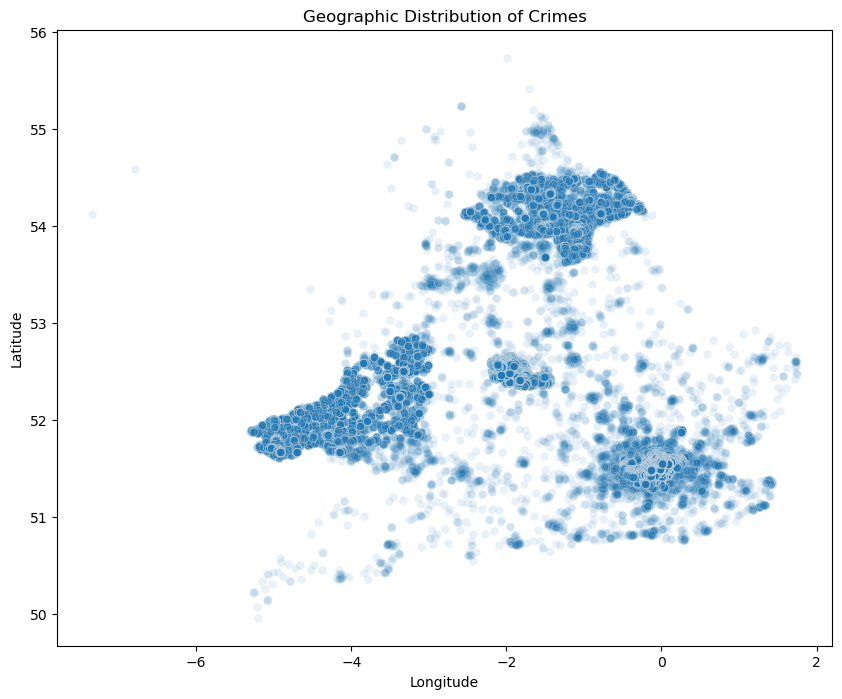

In [ ]:
plt.figure(figsize=(10,8))

sns.scatterplot(
    data=df,
    x="Longitude",
    y="Latitude",
    alpha=0.1
)

plt.title("Geographic Distribution of Crimes")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

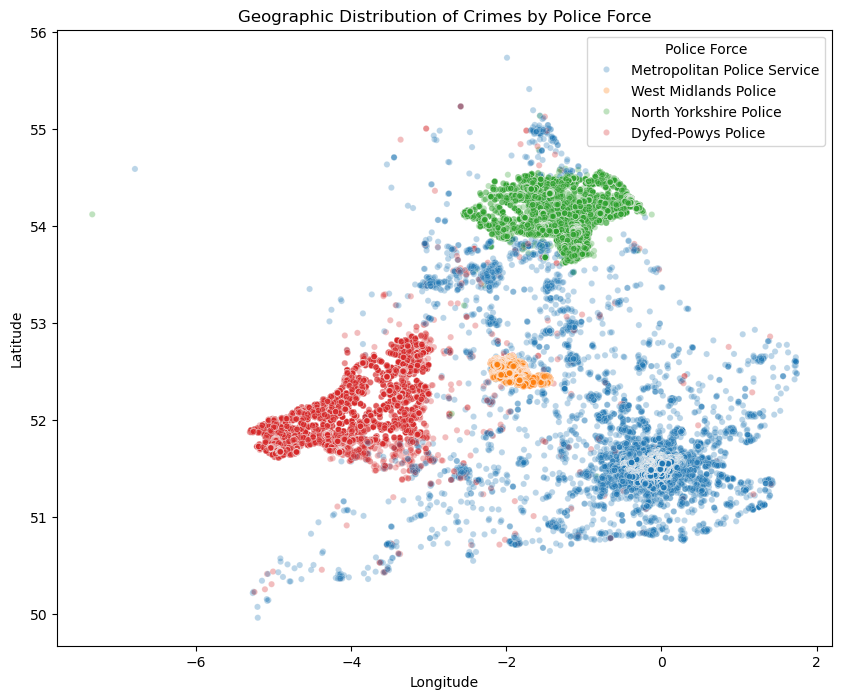

In [ ]:
plt.figure(figsize=(10, 8))

sns.scatterplot(
    data=df,
    x="Longitude",
    y="Latitude",
    hue="Falls within",
    hue_order=force_order,
    alpha=0.3,
    s=20
)

plt.title("Geographic Distribution of Crimes by Police Force")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Police Force")
plt.show()